# Stage 4B: SAMWISE Object Tracking

This notebook uses **SAMWISE** (Infusing Wisdom in SAM2) to track objects in video clips based on text prompts.

**Goal:**
1.  Extract a video clip for a specific action.
2.  Use SAMWISE to segment relevant objects (e.g., "the scraper", "the wooden rail").
3.  Analyze the intersection of masks to determine contact/separation.

In [ ]:
# Install dependencies (run once)
!pip install gdown moviepy spacy hydra-core omegaconf py3_wget bitarray

In [ ]:
import os
from pathlib import Path

# Setup paths
REPO_ROOT = Path("..")
SAMWISE_DIR = Path("SAMWISE_repo").resolve()
PRETRAIN_DIR = SAMWISE_DIR / "pretrain"
MODEL_PATH = PRETRAIN_DIR / "final_model_mevis.pth"

if not SAMWISE_DIR.exists():
    raise FileNotFoundError("SAMWISE repo not found. Please clone it first.")

if not PRETRAIN_DIR.exists():
    PRETRAIN_DIR.mkdir(parents=True, exist_ok=True)

# Download model weights if missing
if not MODEL_PATH.exists():
    print("Downloading SAMWISE weights...")
    # Link from inference_demo.py for MeViS model
    !gdown --fuzzy https://drive.google.com/file/d/1Molt2up2bP41ekeczXWQU-LWTskKJOV2/view?usp=sharing -O {MODEL_PATH}
else:
    print(f"Weights found at {MODEL_PATH}")

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import spacy

# Add SAMWISE repo to path
if str(SAMWISE_DIR) not in sys.path:
    sys.path.append(str(SAMWISE_DIR))

# Import SAMWISE modules (suppress warnings if possible)
import warnings
warnings.filterwarnings("ignore")

try:
    import hydra
    from models.samwise import build_samwise
    from util.misc import on_load_checkpoint
    from datasets.transform_utils import vis_add_mask
except ImportError as e:
    print(f"Error importing SAMWISE modules: {e}")
    print("Make sure dependencies are installed: pip install hydra-core omegaconf")
    print("Make sure you are running this notebook from 'labels_check' directory and SAMWISE_repo is present.")

# Load Spacy for noun extraction
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading en_core_web_sm...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

print("Imports ready.")

In [ ]:
# Load Data
DATA_DIR = Path("../data")
LABELS_PATH = DATA_DIR / "labels" / "action_labels_llm_clean_refined.csv"
VIDEO_DIR = DATA_DIR / "ego4d_data" / "videos" / "v2" / "full_scale"

def video_path_for_uid(uid: str) -> Path:
    return VIDEO_DIR / f"{uid}.mp4"

if LABELS_PATH.exists():
    df = pd.read_csv(LABELS_PATH)
    # Ensure timestamp is numeric
    df["timestamp_sec"] = pd.to_numeric(df["timestamp_sec"], errors="coerce")
    print(f"Loaded {len(df)} labels.")
else:
    print("Labels file not found.")

In [ ]:
import subprocess

def extract_video_segment(video_path, t_start, t_end, output_path):
    """Extract a video segment using ffmpeg."""
    duration = max(0.1, t_end - t_start)
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(t_start),
        "-t", str(duration),
        "-i", str(video_path),
        "-c:v", "libx264", "-preset", "ultrafast",
        "-c:a", "copy",
        str(output_path)
    ]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return True
    except subprocess.CalledProcessError:
        return False

def extract_objects_from_narration(text):
    """Extract noun chunks from text using SpaCy."""
    doc = nlp(text)
    # Filter for noun chunks that are not just pronouns
    objects = [chunk.text for chunk in doc.noun_chunks if chunk.root.pos_ != "PRON"]
    # Clean up (remove '#C C' which is common in Ego4D narrations)
    objects = [obj for obj in objects if "#C" not in obj and "C" != obj]
    return list(set(objects)) # Unique

In [ ]:
# SAMWISE Configuration
class Args:
    def __init__(self):
        self.backbone = 'ub_b' # Default backbone
        self.num_frames = 8
        self.num_queries = 1
        self.masks = True
        self.no_aux_loss = True
        self.set_cost_class = 2.0
        self.set_cost_mask = 5.0
        self.set_cost_dice = 2.0
        self.dice_loss_coef = 5.0
        self.mask_loss_coef = 2.0
        self.eos_coef = 0.1
        self.focal_alpha = 0.25
        self.hidden_dim = 256
        self.position_embedding = 'sine'
        self.enc_layers = 6
        self.dec_layers = 6
        self.dim_feedforward = 2048
        self.dropout = 0.1
        self.nheads = 8
        self.pre_norm = False
        self.eval_clip_window = 3 # Batch size for inference
        self.num_workers = 0
        self.threshold = 0.5
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.resume = str(MODEL_PATH)
        self.HSA = True # Use Hybrid Semantic Attention
        self.use_cme_head = False # Use CME head
        self.image_level = False
        self.sam2_version = "large" # Default SAM2 version
        self.motion_prompt = False
        self.disable_pred_obj_score = False
        self.HSA_patch_size = [8, 4, 2]
        self.adapter_dim = 256
        self.fusion_stages_txt = [4, 8, 12]
        self.fusion_stages = [1, 2, 3]
        self.use_cme_head = False
        self.switch_mem = 'reweight'
        self.cme_decision_window = 4

# Load Model (Global)
print("Loading SAMWISE model...")
args = Args()
model = build_samwise(args)
model.to(args.device)

# Load weights
if args.resume:
    checkpoint = torch.load(args.resume, map_location='cpu')
    if list(checkpoint['model'].keys())[0].startswith('module'):
        checkpoint['model'] = {k.replace('module.', ''): v for k, v in checkpoint['model'].items()}        
    checkpoint = on_load_checkpoint(model, checkpoint)
    model.load_state_dict(checkpoint['model'], strict=False)
model.eval()
print("Model loaded.")

In [ ]:
from datasets.transform_utils import VideoEvalDataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm.notebook import tqdm

def run_samwise_on_clip(clip_path, text_prompts):
    """Run SAMWISE on a video clip for a list of text prompts."""
    # 1. Extract frames
    frames_folder = Path("temp_frames")
    import shutil
    if frames_folder.exists():
        shutil.rmtree(frames_folder)
    frames_folder.mkdir()
    
    os.system(f"ffmpeg -i {clip_path} -loglevel error -vf fps=10 {frames_folder}/frame_%05d.png")
    frames_list = sorted([f.stem for f in frames_folder.glob("*.png")])
    ext = ".png"
    
    if not frames_list:
        print("No frames extracted.")
        return None, None, None

    results = {}
    
    # 2. Inference
    vd = VideoEvalDataset(str(frames_folder), frames_list, ext=ext)
    dl = DataLoader(vd, batch_size=args.eval_clip_window, num_workers=0, shuffle=False)
    origin_w, origin_h = vd.origin_w, vd.origin_h
    
    print(f"Running inference for prompts: {text_prompts}")
    
    for prompt in text_prompts:
        all_pred_masks = []
        for imgs, clip_frames_ids in dl: # tqdm(dl, desc=f"Prompt: {prompt}", leave=False):
            imgs = imgs.to(args.device)
            img_h, img_w = imgs.shape[-2:]
            size = torch.as_tensor([int(img_h), int(img_w)]).to(args.device)
            target = {"size": size, 'frame_ids': clip_frames_ids.tolist()}

            with torch.no_grad():
                outputs = model([imgs], [prompt], [target])

            pred_masks = outputs["pred_masks"]
            pred_masks = pred_masks.unsqueeze(0)
            pred_masks = F.interpolate(pred_masks, size=(origin_h, origin_w), mode='bilinear', align_corners=False) 
            pred_masks = (pred_masks.sigmoid() > args.threshold)[0].cpu() 
            all_pred_masks.append(pred_masks)
            
        results[prompt] = torch.cat(all_pred_masks, dim=0).numpy()
        
    return results, frames_folder, frames_list

# Test SAMWISE on a specific action

Action 49: Locomotion
Narration: #C C works out in the house
Time: 1046.28s - 1067.24s
Testing Prompts: ['purple block']
Clip extracted to /tmp/tmp64y8x9ky/test_clip.mp4
Running inference for prompts: ['purple block']
Prompt 'purple block' - Frame 0: Mask max val=False, Pixels=0


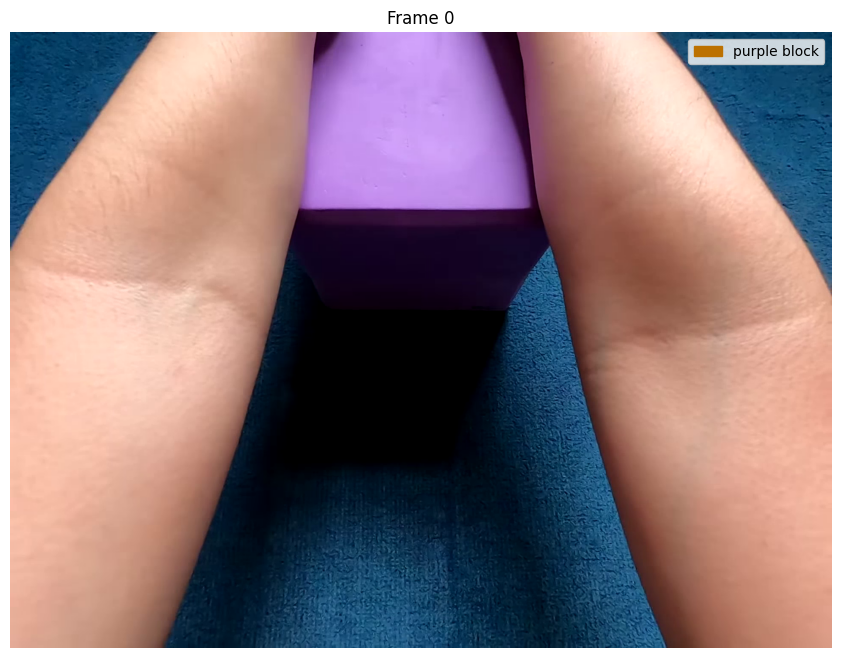

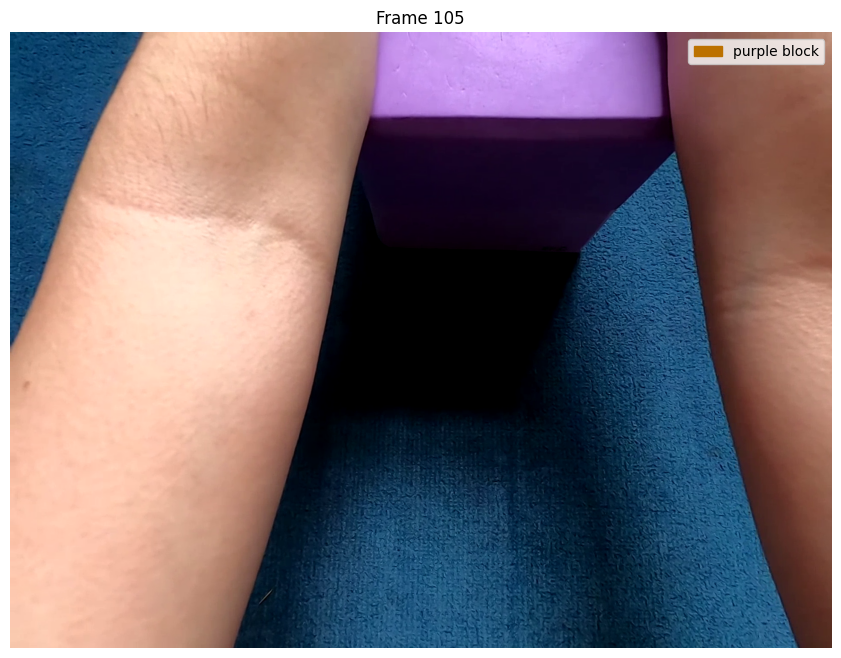

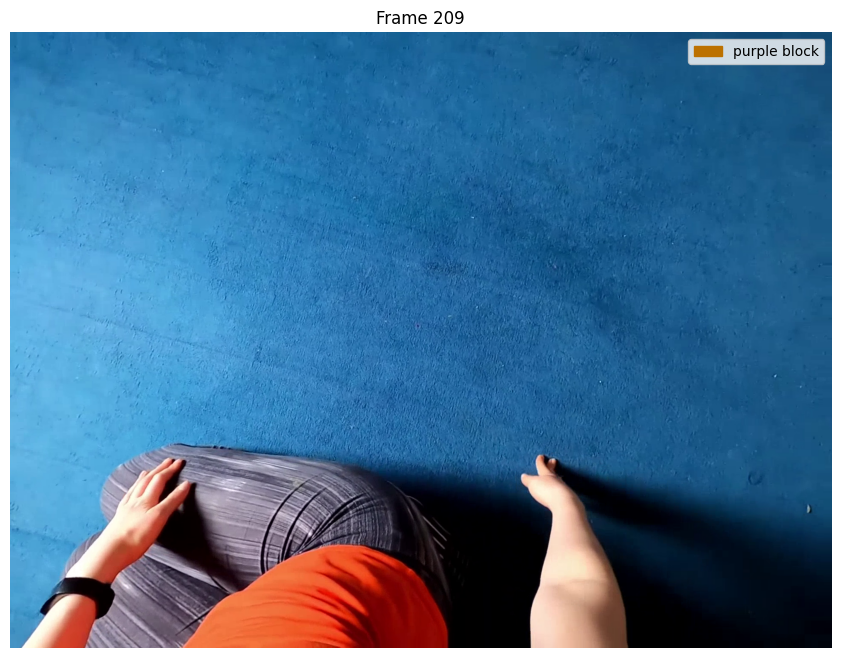

In [11]:
# Configuration
VIDEO_UID = "6a1bdcdb-0def-4cbb-87ab-0da83b63552c" # Replace with your UID
ACTION_INDEX = 49 # Replace with row index to test

# Get Action Info
rows = df[df["video_uid"] == VIDEO_UID].sort_values("timestamp_sec").reset_index(drop=True)
row = rows.iloc[ACTION_INDEX]
t_start = row["timestamp_sec"]
if ACTION_INDEX + 1 < len(rows):
    t_end = rows.iloc[ACTION_INDEX+1]["timestamp_sec"]
else:
    t_end = t_start + 5.0 # Default duration if last action

narration = row["narration_text"]
action_type = row["action"]

print(f"Action {ACTION_INDEX}: {action_type}")
print(f"Narration: {narration}")
print(f"Time: {t_start:.2f}s - {t_end:.2f}s")

# Extract Objects - Let's try manual prompts to debug
# objects = extract_objects_from_narration(narration)
objects = ["purple block"] 
print(f"Testing Prompts: {objects}")

# Extract Clip
import tempfile
with tempfile.TemporaryDirectory() as tmpdir:
    clip_path = Path(tmpdir) / "test_clip.mp4"
    if extract_video_segment(video_path_for_uid(VIDEO_UID), t_start, t_end, clip_path):
        print(f"Clip extracted to {clip_path}")
        
        # Run SAMWISE
        masks_dict, frames_dir, frames_list = run_samwise_on_clip(clip_path, objects)
        
        # Visualize Results (First, Middle, Last frame)
        if masks_dict:
            indices_to_show = [0, len(frames_list)//2, len(frames_list)-1]
            from tools.colormap import colormap
            colors = colormap().astype('uint8').tolist()
            
            for idx in indices_to_show:
                if idx >= len(frames_list): continue
                frame_name = frames_list[idx]
                img_path = frames_dir / f"{frame_name}.png"
                img = Image.open(img_path).convert("RGBA")
                
                plt.figure(figsize=(12, 8))
                plt.imshow(img)
                plt.title(f"Frame {idx}")
                
                # Overlay masks
                combined_mask_img = img.copy()
                found_any = False
                
                for i, (obj, masks) in enumerate(masks_dict.items()):
                    mask = masks[idx] # (H, W)
                    
                    # Debug info
                    if idx == 0:
                        print(f"Prompt '{obj}' - Frame {idx}: Mask max val={mask.max()}, Pixels={mask.sum()}")
                    
                    if mask.sum() > 0:
                        found_any = True
                        color = colors[i % len(colors)]
                        # Simple overlay
                        mask_img = Image.fromarray((mask * 255).astype('uint8'), mode='L')
                        overlay = Image.new('RGBA', mask_img.size, tuple(color) + (128,)) # Semi-transparent color
                        combined_mask_img.paste(overlay, (0,0), mask_img)
                
                plt.imshow(combined_mask_img)
                # Create legend
                import matplotlib.patches as mpatches
                patches = [mpatches.Patch(color=np.array(colors[i%len(colors)])/255, label=obj) for i, obj in enumerate(masks_dict.keys())]
                plt.legend(handles=patches, loc='upper right')
                plt.axis('off')
                plt.show()
                
                if not found_any:
                    print(f"Warning: No masks found for Frame {idx}")
    else:
        print("Failed to extract clip.")